In [23]:
import pandas as pd        # For data manipulation
import numpy as np         # For numerical operations
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns      # For nicer plots
from sklearn.preprocessing import StandardScaler  # For scaling RFM
from sklearn.cluster import KMeans                # For clustering

In [24]:
import pandas as pd
rfm = pd.read_excel(r"C:\Users\sohit\OneDrive\Documents\Customer_CLV_Project\Data\Final_Clean_Data.xlsx",
                    sheet_name='RFM_Table')

rfm.head()

,CustomerID,Monetary,Frequency,LastPurchaseDate,Recency,RecencyScore,MonetaryScore,FrequencyScore,RFM_Total,Segment,SnapshotDate
0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,2011-12-10 12:50:00
1,12346.0,77183.60,209.0,2011-12-09 12:20:00,1.0,5.0,5.0,5.0,15.0,VIP,NaT
2,12347.0,4310.00,201.0,2011-12-08 15:54:00,1.0,5.0,5.0,5.0,15.0,VIP,NaT
3,12348.0,1797.24,124.0,2011-12-08 12:07:00,2.0,5.0,4.0,5.0,14.0,VIP,NaT
4,12349.0,1757.55,97.0,2011-12-07 09:02:00,3.0,5.0,4.0,5.0,14.0,VIP,NaT


In [25]:
rfm.shape #size of table


(4339, 11)

In [26]:
rfm = rfm.dropna(subset=['Recency','Frequency','Monetary'])
#remove the NaN row
rfm.shape

(4338, 11)

In [27]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
X.head()

,Recency,Frequency,Monetary
1,1.0,209.0,77183.60
2,1.0,201.0,4310.00
3,2.0,124.0,1797.24
4,3.0,97.0,1757.55
5,1.0,93.0,334.40


In [28]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.91534006, 26.5980312 ,  8.35866818],
       [-0.91534006, 25.55868014,  0.25096626],
       [-0.90534032, 15.55492613, -0.02859601],
       [-0.89534058, 12.04711628, -0.0330118 ],
       [-0.91534006, 11.52744075, -0.19134727]])

In [29]:
wcss = []
from sklearn.cluster import KMeans                # For clustering
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss

[13014.000000000007,
 10135.692384144953,
 7542.613695813698,
 4666.595154831483,
 3971.1551713236267,
 2773.259222287279,
 2346.100201499019,
 1867.2858803291638,
 1607.1934816844323,
 1338.410210172846]

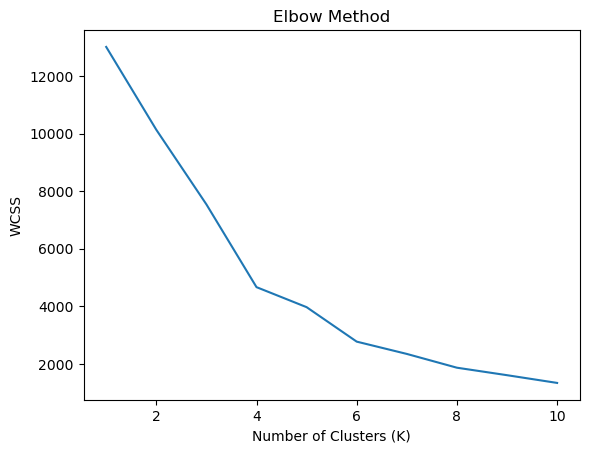

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS") 
plt.title("Elbow Method")
plt.show()

In [31]:
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit model
kmeans.fit(X_scaled)

# Assign cluster labels
rfm['Cluster'] = kmeans.labels_

rfm.head(10)

,CustomerID,Monetary,Frequency,LastPurchaseDate,Recency,RecencyScore,MonetaryScore,FrequencyScore,RFM_Total,Segment,SnapshotDate,Cluster
1,12346.0,77183.60,209.0,2011-12-09 12:20:00,1.0,5.0,5.0,5.0,15.0,VIP,NaT,2
2,12347.0,4310.00,201.0,2011-12-08 15:54:00,1.0,5.0,5.0,5.0,15.0,VIP,NaT,2
3,12348.0,1797.24,124.0,2011-12-08 12:07:00,2.0,5.0,4.0,5.0,14.0,VIP,NaT,2
4,12349.0,1757.55,97.0,2011-12-07 09:02:00,3.0,5.0,4.0,5.0,14.0,VIP,NaT,2
5,12350.0,334.40,93.0,2011-12-08 19:28:00,1.0,5.0,2.0,5.0,12.0,Loyal,NaT,2
6,12352.0,2506.04,91.0,2011-12-09 12:00:00,1.0,5.0,5.0,5.0,15.0,VIP,NaT,2
7,12353.0,89.00,86.0,2011-12-06 12:20:00,4.0,5.0,1.0,5.0,11.0,Loyal,NaT,2
8,12354.0,1079.40,73.0,2011-12-08 12:12:00,2.0,5.0,4.0,5.0,14.0,VIP,NaT,2
9,12355.0,459.40,63.0,2011-11-01 10:27:00,39.0,3.0,2.0,5.0,10.0,Loyal,NaT,1
10,12356.0,2811.43,62.0,2011-12-08 09:05:00,2.0,5.0,5.0,5.0,15.0,VIP,NaT,1


In [32]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,246.341912,1.585478,1461.785873
1,41.022882,4.883117,1809.480344
2,1.875000,121.750000,11132.153750
3,90.000000,5.125000,172508.526250


In [33]:
rfm['Cluster'].value_counts()

Cluster
1    3234
0    1088
2       8
3       8
Name: count, dtype: int64

In [35]:
pd.crosstab(rfm['Segment'], rfm['Cluster'])

Cluster,0,1,2,3
Segment,,,,
At Risk,583,424,0,0
Lost,152,0,0,0
Loyal,21,1132,2,2
Potential,332,1153,0,4
VIP,0,525,6,2


In [36]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\sohit\OneDrive\Documents\Customer_CLV_Project\Data\Final_Clean_Data.xlsx",
    sheet_name='Cleaned'   # <-- change if your sheet name is different
)
df.head() #time taking about 160s

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [37]:
df.shape

(397884, 9)

In [38]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')

In [39]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [40]:
cutoff_date = df['InvoiceDate'].max() - pd.DateOffset(months=3)

df_past = df[df['InvoiceDate'] <= cutoff_date]
df_future = df[df['InvoiceDate'] > cutoff_date]

print("Past shape:", df_past.shape)
print("Future shape:", df_future.shape)

Past shape: (235682, 9)
Future shape: (162202, 9)


In [41]:
future_revenue = (
    df_future
    .groupby('CustomerID')['Revenue']
    .sum()
    .reset_index()
)

future_revenue.columns = ['CustomerID', 'FutureRevenue']

future_revenue.head()

,CustomerID,FutureRevenue
0,12347,1519.14
1,12348,310.00
2,12349,1757.55
3,12352,944.23
4,12356,58.35


In [42]:
snapshot_date = df_past['InvoiceDate'].max()

rfm_reg = (
    df_past
    .groupby('CustomerID')
    .agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'Revenue': 'sum'
    })
    .reset_index()
)

rfm_reg.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm_reg.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,234,1,77183.60
1,12347,38,5,2790.86
2,12348,157,3,1487.24
3,12350,218,1,334.40
4,12352,170,5,1561.81


In [43]:
rfm_reg['AvgOrderValue'] = rfm_reg['Monetary'] / rfm_reg['Frequency']

In [44]:
purchase_interval = (
    df_past
    .sort_values(['CustomerID', 'InvoiceDate'])
    .groupby('CustomerID')['InvoiceDate']
    .apply(lambda x: x.diff().dt.days.mean())
    .reset_index()
)

purchase_interval.columns = ['CustomerID', 'PurchaseInterval']

rfm_reg = rfm_reg.merge(purchase_interval, on='CustomerID', how='left')

In [45]:
rfm_reg['PurchaseInterval'] = rfm_reg['PurchaseInterval'].fillna(0)

In [46]:
rfm_reg = rfm_reg.merge(future_revenue, on='CustomerID', how='left')
rfm_reg['FutureRevenue'] = rfm_reg['FutureRevenue'].fillna(0)

rfm_reg.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,PurchaseInterval,FutureRevenue
0,12346,234,1,77183.60,77183.600000,0.000000,0.00
1,12347,38,5,2790.86,558.172000,1.910569,1519.14
2,12348,157,3,1487.24,495.746667,4.037037,310.00
3,12350,218,1,334.40,334.400000,0.000000,0.00
4,12352,170,5,1561.81,312.362000,0.918919,944.23


In [47]:
X = rfm_reg[['Recency', 'Frequency', 'Monetary', 
             'AvgOrderValue', 'PurchaseInterval']]

y = rfm_reg['FutureRevenue']

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 3493.5785633923138
R²: 0.6670514623877402


In [51]:
rfm_reg['Predicted_CLV'] = model.predict(X)

In [53]:
rfm.columns

Index(['CustomerID', 'Monetary', 'Frequency', 'LastPurchaseDate', 'Recency',
       'RecencyScore', 'MonetaryScore', 'FrequencyScore', 'RFM_Total',
       'Segment', 'SnapshotDate', 'Cluster'],
      dtype='object')

In [54]:
rfm_reg = rfm_reg.merge(
    rfm[['CustomerID', 'Segment']],
    on='CustomerID',
    how='left'
)

rfm_reg.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,PurchaseInterval,FutureRevenue,Predicted_CLV,Segment
0,12346,234,1,77183.60,77183.600000,0.000000,0.00,-55527.717306,VIP
1,12347,38,5,2790.86,558.172000,1.910569,1519.14,1263.783992,VIP
2,12348,157,3,1487.24,495.746667,4.037037,310.00,618.034688,VIP
3,12350,218,1,334.40,334.400000,0.000000,0.00,254.158433,Loyal
4,12352,170,5,1561.81,312.362000,0.918919,944.23,787.318752,VIP


In [55]:
strategy_table = (
    rfm_reg
    .groupby('Segment')['Predicted_CLV']
    .mean()
    .reset_index()
)

strategy_table

,Segment,Predicted_CLV
0,At Risk,408.949135
1,Lost,409.777623
2,Loyal,923.773875
3,Potential,888.139615
4,VIP,1197.015164


In [56]:
strategy_table['Suggested Action'] = strategy_table['Segment'].map({
    'VIP': 'Premium loyalty rewards & exclusive access',
    'Loyal': 'Upsell & cross-sell campaigns',
    'Potential': 'Engagement & personalized offers',
    'At Risk': 'Retention & discount campaigns',
    'Lost': 'Low-cost automated win-back'
})

strategy_table

,Segment,Predicted_CLV,Suggested Action
0,At Risk,408.949135,Retention & discount campaigns
1,Lost,409.777623,Low-cost automated win-back
2,Loyal,923.773875,Upsell & cross-sell campaigns
3,Potential,888.139615,Engagement & personalized offers
4,VIP,1197.015164,Premium loyalty rewards & exclusive access


In [58]:
rfm_reg.to_csv(
    r"C:\Users\sohit\OneDrive\Documents\Customer_CLV_Project\Data\customer_clv_final.csv",
    index=False
)

In [59]:
import os
os.listdir(r"C:\Users\sohit\OneDrive\Documents\Customer_CLV_Project\Data")

['customer_clv_final.csv',
 'Final_Clean_Data.xlsx',
 'online+retail.zip',
 '~$Final_Clean_Data.xlsx']